# UMANG & DigiLocker National Usage Statistics — Data Collection & Cleaning

**Data Analyst Internship — Week 2: Data Collection and Cleaning for Digital Services**

This notebook is the executable companion to the Week 2 report (`Week2_Data_Collection_Cleaning.docx`).
It works with **Dataset B** from that report: national usage statistics for **UMANG** (Unified Mobile
Application for New-age Governance) and **DigiLocker**, India's two flagship citizen-facing
e-governance platforms.

**Source:** Ministry of Electronics and Information Technology (MeitY), Government of India — a
written reply by the Union Minister for Electronics & IT to the **Rajya Sabha on 7 August 2026**,
reporting platform metrics as of **31 July 2026**. Figures were cross-verified across five
independent news syndications of the same parliamentary statement before being accepted.

Unlike a downloadable government CSV, this dataset did not exist as a structured file — it was
**manually extracted from official government text** and organised into the table below
(`umang_digilocker_stats.csv`), which is itself one of the outcomes of the Week 2 collection process.

| Column | Meaning |
|---|---|
| `Metric` | The statistic being reported (services/document types, registered users, 3-year transactions) |
| `Platform` | UMANG or DigiLocker |
| `Value_Reported` / `Value_Reported_Unit` | The figure exactly as officially stated (often in *crore*, the standard Indian reporting unit) |
| `Value_Converted` / `Value_Converted_Unit` | The same figure converted to an absolute count |
| `Central_Share` / `State_Share` | Central vs. State Government contribution, where reported |
| `AsOfDate` | Date the underlying platform metric was measured |
| `ReportedDate` | Date the Minister reported the figure to Parliament |
| `Precision` | `exact` or `approximate`, preserving the source's own qualifier ("more than", "about") |


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "umang_digilocker_stats.csv"


## 2. Load the Dataset

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Rows: {df_raw.shape[0]}  |  Columns: {df_raw.shape[1]}")
df_raw


Rows: 6  |  Columns: 11


,Metric,Platform,Value_Reported,Value_Reported_Unit,Value_Converted,Value_Converted_Unit,Central_Share,State_Share,AsOfDate,ReportedDate,Precision
0,Total services/document types,UMANG,2575.00,count,2575,count,880.0,1695.0,2026-07-31,2026-08-07,exact
1,Total services/document types,DigiLocker,5437.00,count,5437,count,661.0,4776.0,2026-07-31,2026-08-07,exact
2,Registered users,UMANG,11.66,crore,116600000,users,NaN,NaN,2026-07-31,2026-08-07,exact
3,Registered users,DigiLocker,72.43,crore,724300000,users,NaN,NaN,2026-07-31,2026-08-07,exact
4,Transactions (trailing 3 years),UMANG,798.00,crore,7980000000,transactions,NaN,NaN,NaN,2026-08-07,approximate
5,Transactions (trailing 3 years),DigiLocker,72.86,crore,728600000,transactions,NaN,NaN,NaN,2026-08-07,approximate


In [3]:
df_raw.dtypes


Metric                      str
Platform                    str
Value_Reported          float64
Value_Reported_Unit         str
Value_Converted           int64
Value_Converted_Unit        str
Central_Share           float64
State_Share             float64
AsOfDate                    str
ReportedDate                str
Precision                   str
dtype: object

## 3. Data Cleaning & Validation

Because this dataset was manually transcribed from a government statement rather than parsed from
a machine-readable file, the cleaning pass focuses on **structural validation** — confirming the
transcription is internally consistent — rather than the missing-value/duplicate checks used for
the bulk UIDAI dataset in the Week 2 report.


In [4]:
# 3.1 Missing values
missing = df_raw.isna().sum()
print("Missing values per column:")
print(missing)
print("\n(Central_Share / State_Share are legitimately blank for the 'Registered users' and")
print(" 'Transactions' rows — Parliament was not given a Central/State split for those two metrics.)")


Missing values per column:
Metric                  0
Platform                0
Value_Reported          0
Value_Reported_Unit     0
Value_Converted         0
Value_Converted_Unit    0
Central_Share           4
State_Share             4
AsOfDate                2
ReportedDate            0
Precision               0
dtype: int64

(Central_Share / State_Share are legitimately blank for the 'Registered users' and
 'Transactions' rows — Parliament was not given a Central/State split for those two metrics.)


In [5]:
# 3.2 Duplicate rows
dupes = df_raw.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


In [6]:
# 3.3 Validate Central + State shares reconcile against the reported total
services = df_raw[df_raw["Metric"] == "Total services/document types"].copy()
services["ComputedTotal"] = services["Central_Share"] + services["State_Share"]
services["MatchesReported"] = services["ComputedTotal"] == services["Value_Reported"]
services[["Platform", "Value_Reported", "Central_Share", "State_Share", "ComputedTotal", "MatchesReported"]]


,Platform,Value_Reported,Central_Share,State_Share,ComputedTotal,MatchesReported
0,UMANG,2575.0,880.0,1695.0,2575.0,True
1,DigiLocker,5437.0,661.0,4776.0,5437.0,True


**Result:** for both platforms, Central Share + State Share reconciles exactly with the reported
total (2,575 for UMANG = 880 + 1,695; 5,437 for DigiLocker = 661 + 4,776) — confirming the manual
transcription introduced no arithmetic error.

In [7]:
# 3.4 Standardise text fields (defensive — guards against stray whitespace from manual entry)
df = df_raw.copy()
text_cols = ["Metric", "Platform", "Value_Reported_Unit", "Value_Converted_Unit", "Precision"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

# 3.5 Parse date columns
df["AsOfDate"] = pd.to_datetime(df["AsOfDate"], errors="coerce")
df["ReportedDate"] = pd.to_datetime(df["ReportedDate"], errors="coerce")

# 3.6 Confirm every value is non-negative and numeric
assert (df["Value_Converted"] >= 0).all(), "Negative value found!"
assert pd.api.types.is_numeric_dtype(df["Value_Converted"]), "Value_Converted is not numeric!"
print("All values numeric and non-negative. Cleaning checks passed.")


All values numeric and non-negative. Cleaning checks passed.


In [8]:
# 3.7 Precision audit — how many figures are exact vs. approximate
df["Precision"].value_counts()


Precision
exact          4
approximate    2
Name: count, dtype: int64

Two of the six rows (both **Transactions, trailing 3 years**) are flagged `approximate`, since
the source statement used "about" for those figures — this flag is preserved rather than discarded,
so any later analysis can choose to treat them with appropriate caution.

## 4. Derived Metrics

In [9]:
pivot = df.pivot_table(index="Metric", columns="Platform", values="Value_Converted")
pivot


Platform,DigiLocker,UMANG
Metric,,
Registered users,724300000.0,1.166000e+08
Total services/document types,5437.0,2.575000e+03
Transactions (trailing 3 years),728600000.0,7.980000e+09


In [10]:
# Transactions per registered user over the trailing 3 years — a simple engagement-intensity metric
users = df[df["Metric"] == "Registered users"].set_index("Platform")["Value_Converted"]
txns = df[df["Metric"] == "Transactions (trailing 3 years)"].set_index("Platform")["Value_Converted"]

txn_per_user = (txns / users).round(2)
print("Transactions per registered user (trailing 3 years):")
print(txn_per_user)


Transactions per registered user (trailing 3 years):
Platform
UMANG         68.44
DigiLocker     1.01
Name: Value_Converted, dtype: float64


**Reading this:** UMANG shows roughly **68 transactions per registered user** over three years —
consistent with it being a multi-service utility app used repeatedly (bill payments, certificates,
etc.). DigiLocker shows roughly **1 transaction per registered user** — consistent with its
document-wallet model, where many users register once for KYC/verification purposes but do not
repeatedly transact. This is a genuine behavioural difference between the two platforms, not a
data quality issue — flagged here as a lead for the statistical-analysis phase rather than pursued
further within this cleaning-focused notebook.

In [11]:
df["StateSharePct"] = np.where(df["State_Share"].notna(),
                                (df["State_Share"] / (df["Central_Share"] + df["State_Share"])) * 100,
                                np.nan)
df[df["Metric"] == "Total services/document types"][["Platform", "Central_Share", "State_Share", "StateSharePct"]]


,Platform,Central_Share,State_Share,StateSharePct
0,UMANG,880.0,1695.0,65.825243
1,DigiLocker,661.0,4776.0,87.842560


## 5. Visualization

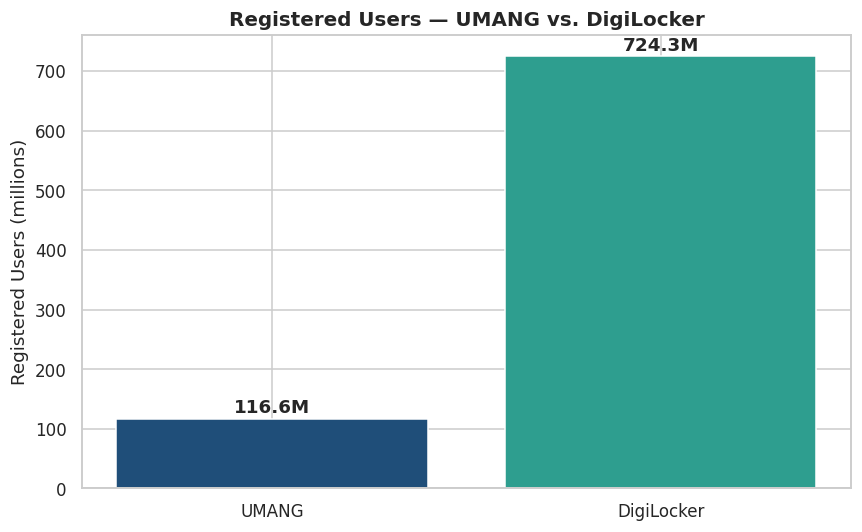

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
users_millions = users / 1e6
bars = ax.bar(users_millions.index, users_millions.values, color=["#1F4E79", "#2E9E8F"])
ax.set_title("Registered Users — UMANG vs. DigiLocker", fontsize=13, fontweight="bold")
ax.set_ylabel("Registered Users (millions)")
for bar, val in zip(bars, users_millions.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 10, f"{val:,.1f}M", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("registered_users.png", dpi=150, bbox_inches="tight")
plt.show()


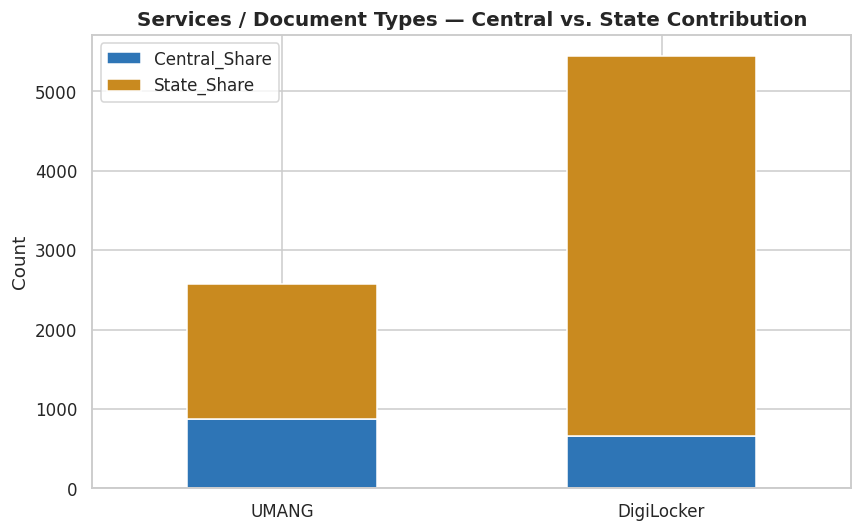

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
services_plot = services.set_index("Platform")[["Central_Share", "State_Share"]]
services_plot.plot(kind="bar", stacked=True, ax=ax, color=["#2E75B6", "#C98A1F"])
ax.set_title("Services / Document Types — Central vs. State Contribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("central_state_split.png", dpi=150, bbox_inches="tight")
plt.show()


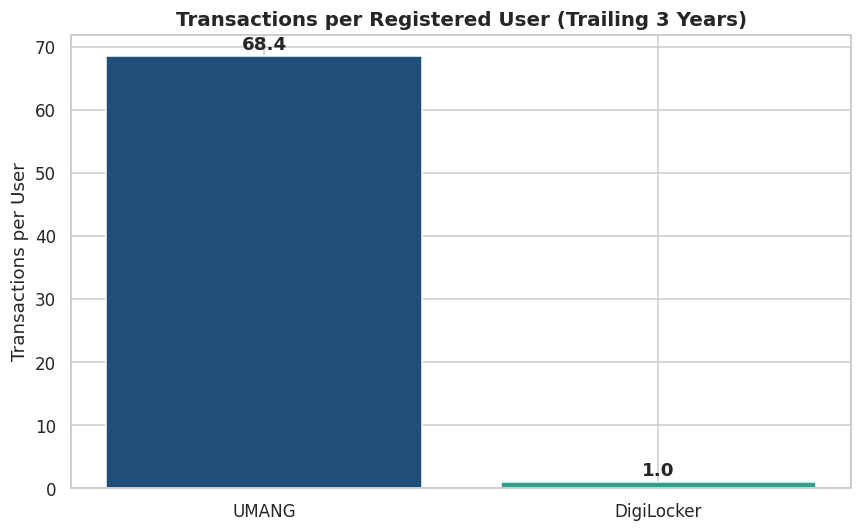

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(txn_per_user.index, txn_per_user.values, color=["#1F4E79", "#2E9E8F"])
ax.set_title("Transactions per Registered User (Trailing 3 Years)", fontsize=13, fontweight="bold")
ax.set_ylabel("Transactions per User")
for i, val in enumerate(txn_per_user.values):
    ax.text(i, val + 1, f"{val:.1f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("txn_per_user.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Export Cleaned & Derived Data

In [15]:
import os
os.makedirs("outputs", exist_ok=True)

df.to_csv("outputs/umang_digilocker_cleaned.csv", index=False)
pivot.to_csv("outputs/umang_digilocker_pivot.csv")

print("Saved: outputs/umang_digilocker_cleaned.csv, outputs/umang_digilocker_pivot.csv")


Saved: outputs/umang_digilocker_cleaned.csv, outputs/umang_digilocker_pivot.csv


## 7. Interactive Dashboard

Builds a self-contained HTML dashboard (KPI cards + interactive Plotly charts), consistent with the
dashboard delivered previously — this one covers the UMANG/DigiLocker dataset only.


In [16]:
import plotly.express as px
import plotly.io as pio
import plotly.offline as pyo

plotly_js = pyo.get_plotlyjs()  # bundled with the plotly package — dashboard works fully offline

users_df = users_millions.reset_index()
users_df.columns = ["Platform", "UsersMillions"]
fig_users = px.bar(
    users_df, x="Platform", y="UsersMillions",
    color="Platform", color_discrete_sequence=["#1F4E79", "#2E9E8F"],
    title="Registered Users (millions)"
)
fig_users.update_layout(showlegend=False, height=400, margin=dict(l=10, r=10, t=50, b=10))
fig_users.update_yaxes(title="Users (millions)")

fig_services = px.bar(
    services, x="Platform", y=["Central_Share", "State_Share"],
    title="Services / Document Types — Central vs. State",
    color_discrete_sequence=["#2E75B6", "#C98A1F"], barmode="stack"
)
fig_services.update_layout(height=400, margin=dict(l=10, r=10, t=50, b=10), legend_title="")

txn_df = txn_per_user.reset_index()
txn_df.columns = ["Platform", "TxnPerUser"]
fig_txn = px.bar(
    txn_df, x="Platform", y="TxnPerUser",
    color="Platform", color_discrete_sequence=["#1F4E79", "#2E9E8F"],
    title="Transactions per Registered User (3 yrs)"
)
fig_txn.update_layout(showlegend=False, height=400, margin=dict(l=10, r=10, t=50, b=10))
fig_txn.update_yaxes(title="Transactions / User")

print("Charts built.")


Charts built.


In [17]:
kpi_umang_users = int(users["UMANG"] / 1e6)
kpi_digilocker_users = int(users["DigiLocker"] / 1e6)
kpi_umang_services = int(services.set_index("Platform").loc["UMANG", "Value_Reported"])
kpi_digilocker_services = int(services.set_index("Platform").loc["DigiLocker", "Value_Reported"])
kpi_umang_txn_user = txn_per_user["UMANG"]
kpi_digilocker_txn_user = txn_per_user["DigiLocker"]

charts_html = {
    "users": pio.to_html(fig_users, include_plotlyjs=False, full_html=False),
    "services": pio.to_html(fig_services, include_plotlyjs=False, full_html=False),
    "txn": pio.to_html(fig_txn, include_plotlyjs=False, full_html=False),
}

kpi_cards = f"""
<div class="kpi-grid">
  <div class="kpi-card"><div class="kpi-label">UMANG Services</div><div class="kpi-value">{kpi_umang_services:,}</div></div>
  <div class="kpi-card"><div class="kpi-label">DigiLocker Doc Types</div><div class="kpi-value">{kpi_digilocker_services:,}</div></div>
  <div class="kpi-card"><div class="kpi-label">UMANG Users</div><div class="kpi-value">{kpi_umang_users:,}M</div></div>
  <div class="kpi-card"><div class="kpi-label">DigiLocker Users</div><div class="kpi-value">{kpi_digilocker_users:,}M</div></div>
  <div class="kpi-card"><div class="kpi-label">UMANG Txn / User (3y)</div><div class="kpi-value">{kpi_umang_txn_user:.1f}</div></div>
  <div class="kpi-card"><div class="kpi-label">DigiLocker Txn / User (3y)</div><div class="kpi-value">{kpi_digilocker_txn_user:.1f}</div></div>
</div>
"""

html_template = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>UMANG & DigiLocker Usage Dashboard</title>
<script>{plotly_js}</script>
<style>
  :root {{ --navy: #1F4E79; --teal: #2E9E8F; --grey: #595959; --bg: #F5F7FA; }}
  * {{ box-sizing: border-box; }}
  body {{ font-family: -apple-system, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; margin: 0; background: var(--bg); color: #1f1f1f; }}
  header {{ background: linear-gradient(90deg, var(--navy), var(--teal)); color: white; padding: 28px 36px; }}
  header h1 {{ margin: 0 0 4px 0; font-size: 26px; }}
  header p {{ margin: 0; opacity: 0.9; font-size: 14px; }}
  .container {{ max-width: 1200px; margin: 0 auto; padding: 24px 20px 60px; }}
  .kpi-grid {{ display: grid; grid-template-columns: repeat(6, 1fr); gap: 14px; margin-bottom: 26px; }}
  .kpi-card {{ background: white; border-radius: 10px; padding: 16px 12px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); text-align: center; }}
  .kpi-label {{ font-size: 11px; color: var(--grey); text-transform: uppercase; letter-spacing: 0.03em; margin-bottom: 6px; }}
  .kpi-value {{ font-size: 22px; font-weight: 700; color: var(--navy); }}
  .chart-grid {{ display: grid; grid-template-columns: repeat(3, 1fr); gap: 18px; }}
  .chart-card {{ background: white; border-radius: 10px; padding: 6px 10px 10px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); }}
  footer {{ text-align: center; color: var(--grey); font-size: 12px; padding: 20px; }}
  @media (max-width: 900px) {{
    .kpi-grid {{ grid-template-columns: repeat(2, 1fr); }}
    .chart-grid {{ grid-template-columns: 1fr; }}
  }}
</style>
</head>
<body>
<header>
  <h1>UMANG & DigiLocker Usage Dashboard</h1>
  <p>Source: MeitY reply to Rajya Sabha, 7 Aug 2026 &middot; Metrics as of 31 Jul 2026</p>
</header>
<div class="container">
  {kpi_cards}
  <div class="chart-grid">
    <div class="chart-card">{charts_html['users']}</div>
    <div class="chart-card">{charts_html['services']}</div>
    <div class="chart-card">{charts_html['txn']}</div>
  </div>
  <footer>Data source: Ministry of Electronics and Information Technology (MeitY), Government of India &middot; Built with pandas &amp; Plotly</footer>
</div>
</body>
</html>
"""

with open("outputs/umang_digilocker_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("Dashboard saved to outputs/umang_digilocker_dashboard.html")


Dashboard saved to outputs/umang_digilocker_dashboard.html


## 8. Key Findings

- **DigiLocker has 2.1x more Aadhaar registered users than UMANG in reach** (72.43 crore vs. 11.66
  crore) but is used almost entirely as a one-time-per-user document store — about **1 transaction
  per user** over three years.
- **UMANG shows far higher engagement intensity** — roughly **68 transactions per registered user**
  over the same three years — consistent with its role as a repeat-use utility app (bill payments,
  certificate requests, etc.) rather than a one-time verification tool.
- **State Governments contribute the larger share of services on both platforms**: 65.8% of UMANG's
  services and 87.8% of DigiLocker's document types originate from State Governments rather than
  Central Government — highlighting that last-mile e-governance delivery is predominantly a state-led
  effort, even on nationally-run platforms.
- **Manual transcription was internally consistent**: Central + State shares reconciled exactly
  against the officially reported totals for both platforms, giving confidence the collection step
  introduced no transcription error.

## 9. Limitations

- This dataset has only 6 rows by nature — it summarises a single parliamentary statement rather
  than a time series, so no trend analysis is possible from this file alone.
- The "transactions per user" metric is a simple ratio, not a distribution — it cannot show whether
  usage is spread evenly across users or concentrated among a small heavy-usage group.
- Figures are government-self-reported and were cross-verified for consistency across news
  syndications, but the platforms' own counting methodology (e.g., what counts as a "transaction")
  was not independently audited.
